<a href="https://colab.research.google.com/github/BeastHunter0041/csci_4170_s26/blob/main/hw5_task3_CSCI4170.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 113.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

# Task 3: NLP and Attention Mechanism

This notebook covers:

- **Part 1:** scaled dot-product attention from scratch using NumPy and pandas only
- **Part 2:** a seq2seq encoder-decoder model with scaled dot-product attention integrated into the encoder
- **Part 3:** training that seq2seq model on a small machine translation dataset and reporting BLEU
- **Part 4**: a simplified Transformer from scratch for the same translation task, then comparing BLEU and runtime

## Dataset
This notebook uses a small subset of the **OPUS Books English-French** dataset for translation.

The subset size is kept around **10k sentence pairs** to match the project requirement.

In [1]:
!pip -q install datasets nltk

In [2]:
import math
import re
import time
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: cuda
GPU: Tesla T4


## Load and inspect the translation dataset

A small English-French subset is used for this task.

In [4]:
raw_ds = load_dataset("opus_books", "en-fr", split="train")
raw_ds = raw_ds.shuffle(seed=SEED).select(range(12000))

pairs = []
for ex in raw_ds:
    src = ex["translation"]["en"].strip()
    tgt = ex["translation"]["fr"].strip()
    if src and tgt:
        pairs.append((src, tgt))

print("Total sentence pairs:", len(pairs))
print("Sample pair:")
print("EN:", pairs[0][0])
print("FR:", pairs[0][1])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Total sentence pairs: 12000
Sample pair:
EN: "Not if it were my own brother!" cried d’Artagnan, as if carried away by his enthusiasm.
FR: «Non, fût-ce mon frère!» s'écria d'Artagnan comme emporté par l'enthousiasme.


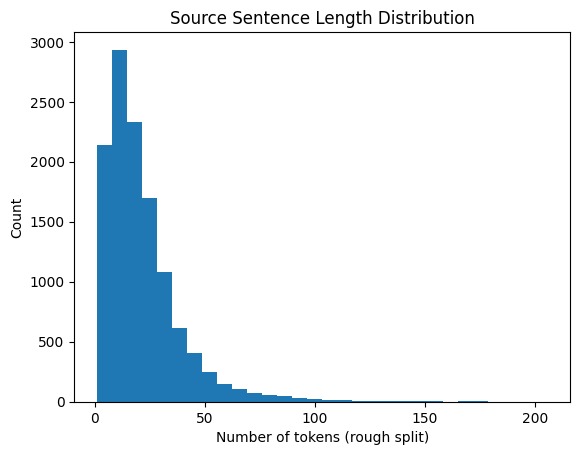

In [5]:
lengths = [len(p[0].split()) for p in pairs]
plt.hist(lengths, bins=30)
plt.title("Source Sentence Length Distribution")
plt.xlabel("Number of tokens (rough split)")
plt.ylabel("Count")
plt.show()

## Part 1: Scaled Dot-Product Attention from Scratch with NumPy and pandas

This section implements scaled dot-product attention manually, without any deep learning library.

In [6]:
def softmax_numpy(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

def scaled_dot_product_attention_numpy(Q, K, V, mask=None):
    dk = Q.shape[-1]
    scores = (Q @ K.T) / np.sqrt(dk)

    if mask is not None:
        scores = np.where(mask == 0, -1e9, scores)

    attention_weights = softmax_numpy(scores, axis=-1)
    output = attention_weights @ V
    return output, attention_weights, scores

### Scaled dot-product attention example

This section demonstrates the attention calculation directly with small matrices.  
It shows the raw attention scores, normalized attention weights, and final weighted output.

In [7]:
tokens = ["I", "like", "flowers"]

Q = np.array([
    [1.0, 0.0, 1.0, 0.0],
    [0.0, 2.0, 0.0, 1.0],
    [1.0, 1.0, 0.0, 1.0]
])

K = np.array([
    [1.0, 1.0, 0.0, 0.0],
    [0.0, 2.0, 1.0, 0.0],
    [1.0, 0.0, 1.0, 1.0]
])

V = np.array([
    [1.0, 0.0, 1.0, 0.0],
    [0.0, 1.0, 0.0, 1.0],
    [1.0, 1.0, 0.0, 0.0]
])

output, weights, scores = scaled_dot_product_attention_numpy(Q, K, V)

print("Raw attention scores:")
display(pd.DataFrame(scores, index=tokens, columns=tokens))

print("Attention weights:")
display(pd.DataFrame(weights, index=tokens, columns=tokens))

print("Attention output:")
display(pd.DataFrame(output, index=tokens, columns=[f"d{i}" for i in range(output.shape[1])]))

Raw attention scores:


,I,like,flowers
I,0.5,0.5,1.0
like,1.0,2.0,0.5
flowers,1.0,1.0,1.0


Attention weights:


,I,like,flowers
I,0.274069,0.274069,0.451863
like,0.231224,0.628532,0.140244
flowers,0.333333,0.333333,0.333333


Attention output:


,d0,d1,d2,d3
I,0.725931,0.725931,0.274069,0.274069
like,0.371468,0.768776,0.231224,0.628532
flowers,0.666667,0.666667,0.333333,0.333333


## Preprocessing for machine translation

This section builds:
- a simple word-level tokenizer
- vocabularies for source and target languages
- train/validation/test splits
- padded DataLoaders

In [8]:
def tokenize(text):
    return re.findall(r"\w+|[^\w\s]", text.lower())

pairs = [(tokenize(src), tokenize(tgt)) for src, tgt in pairs]

MAX_LEN = 20
pairs = [(src, tgt) for src, tgt in pairs if 1 < len(src) <= MAX_LEN and 1 < len(tgt) <= MAX_LEN]

print("Filtered sentence pairs:", len(pairs))
print("Sample tokenized pair:")
print(pairs[0][0])
print(pairs[0][1])

Filtered sentence pairs: 5112
Sample tokenized pair:
['"', 'mr', '.', 'conseil', 'put', 'one', 'over', 'on', 'me', '!', '"']
['monsieur', 'conseil', 'qui', 'me', 'fait', 'poser', '!']


In [9]:
random.shuffle(pairs)

n = len(pairs)
train_end = int(0.8 * n)
val_end = int(0.9 * n)

train_pairs = pairs[:train_end]
val_pairs = pairs[train_end:val_end]
test_pairs = pairs[val_end:]

print(len(train_pairs), len(val_pairs), len(test_pairs))

4089 511 512


### Vocabulary construction

Separate vocabularies are built for the source and target languages.  
Special tokens such as padding, beginning-of-sequence, end-of-sequence, and unknown-word tokens are also included.

In [10]:
PAD = "<pad>"
BOS = "<bos>"
EOS = "<eos>"
UNK = "<unk>"

SPECIAL_TOKENS = [PAD, BOS, EOS, UNK]

def build_vocab(tokenized_sentences, max_vocab_size=8000):
    counter = Counter()
    for sent in tokenized_sentences:
        counter.update(sent)
    most_common = [tok for tok, _ in counter.most_common(max_vocab_size - len(SPECIAL_TOKENS))]
    stoi = {tok: idx for idx, tok in enumerate(SPECIAL_TOKENS + most_common)}
    itos = {idx: tok for tok, idx in stoi.items()}
    return stoi, itos

src_stoi, src_itos = build_vocab([src for src, _ in train_pairs], max_vocab_size=8000)
tgt_stoi, tgt_itos = build_vocab([tgt for _, tgt in train_pairs], max_vocab_size=8000)

SRC_PAD_IDX = src_stoi[PAD]
TGT_PAD_IDX = tgt_stoi[PAD]
SRC_BOS_IDX = src_stoi[BOS]
SRC_EOS_IDX = src_stoi[EOS]
TGT_BOS_IDX = tgt_stoi[BOS]
TGT_EOS_IDX = tgt_stoi[EOS]

print("Source vocab size:", len(src_stoi))
print("Target vocab size:", len(tgt_stoi))

Source vocab size: 6191
Target vocab size: 7281


### Numericalization and batching

The tokenized sentences are converted into integer IDs and padded within each batch so they can be processed by PyTorch models.

In [11]:
def numericalize(tokens, stoi):
    return [stoi.get(tok, stoi[UNK]) for tok in tokens]

class TranslationDataset(Dataset):
    def __init__(self, pairs, src_stoi, tgt_stoi):
        self.pairs = pairs
        self.src_stoi = src_stoi
        self.tgt_stoi = tgt_stoi

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_tokens, tgt_tokens = self.pairs[idx]
        src_ids = [self.src_stoi[BOS]] + numericalize(src_tokens, self.src_stoi) + [self.src_stoi[EOS]]
        tgt_ids = [self.tgt_stoi[BOS]] + numericalize(tgt_tokens, self.tgt_stoi) + [self.tgt_stoi[EOS]]
        return torch.tensor(src_ids), torch.tensor(tgt_ids)

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_padded = nn.utils.rnn.pad_sequence(src_batch, batch_first=True, padding_value=SRC_PAD_IDX)
    tgt_padded = nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True, padding_value=TGT_PAD_IDX)
    return src_padded, tgt_padded

train_ds = TranslationDataset(train_pairs, src_stoi, tgt_stoi)
val_ds = TranslationDataset(val_pairs, src_stoi, tgt_stoi)
test_ds = TranslationDataset(test_pairs, src_stoi, tgt_stoi)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, collate_fn=collate_fn)

In [12]:
src_batch, tgt_batch = next(iter(train_loader))
print("Source batch shape:", src_batch.shape)
print("Target batch shape:", tgt_batch.shape)

Source batch shape: torch.Size([64, 22])
Target batch shape: torch.Size([64, 22])


## Part 2 and Part 3: Seq2Seq with scaled dot-product attention

### Integration approach
The seq2seq model below uses:
- a **bidirectional GRU encoder**
- a **scaled dot-product self-attention layer inside the encoder** to refine encoder outputs
- a **GRU decoder** with attention over the encoder representations

This satisfies the requirement to integrate scaled dot-product attention into the encoder architecture.

In [13]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, q, k, v, mask=None):
        d_k = q.size(-1)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        output = torch.matmul(attn, v)
        return output, attn

In [14]:
class EncoderSelfAttention(nn.Module):
    def __init__(self, dim, dropout=0.1):
        super().__init__()
        self.q_proj = nn.Linear(dim, dim)
        self.k_proj = nn.Linear(dim, dim)
        self.v_proj = nn.Linear(dim, dim)
        self.attn = ScaledDotProductAttention(dropout=dropout)
        self.norm = nn.LayerNorm(dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)
        attn_out, attn_weights = self.attn(q, k, v, src_mask)
        out = self.norm(x + self.dropout(attn_out))
        return out, attn_weights

In [15]:
class Seq2SeqEncoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, enc_hidden_dim, dec_hidden_dim, pad_idx, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(
            emb_dim,
            enc_hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.proj_outputs = nn.Linear(enc_hidden_dim * 2, dec_hidden_dim)
        self.proj_hidden = nn.Linear(enc_hidden_dim * 2, dec_hidden_dim)
        self.self_attn = EncoderSelfAttention(dec_hidden_dim, dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_pad_mask):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.gru(embedded)

        outputs = self.proj_outputs(outputs)

        hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        hidden = torch.tanh(self.proj_hidden(hidden_cat)).unsqueeze(0)

        refined_outputs, attn_weights = self.self_attn(outputs, src_pad_mask)
        return refined_outputs, hidden, attn_weights

In [16]:
class Seq2SeqDecoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, pad_idx, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.query_proj = nn.Linear(hidden_dim, hidden_dim)
        self.attn = ScaledDotProductAttention(dropout=dropout)
        self.gru = nn.GRU(emb_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim + hidden_dim + emb_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, encoder_outputs, src_pad_mask):
        input_token = input_token.unsqueeze(1)
        embedded = self.dropout(self.embedding(input_token))

        query = self.query_proj(hidden[-1]).unsqueeze(1)
        context, attn_weights = self.attn(query, encoder_outputs, encoder_outputs, src_pad_mask)
        rnn_input = torch.cat([embedded, context], dim=-1)

        output, hidden = self.gru(rnn_input, hidden)

        logits = self.fc_out(torch.cat([output.squeeze(1), context.squeeze(1), embedded.squeeze(1)], dim=-1))
        return logits, hidden, attn_weights

In [17]:
class Seq2SeqAttentionModel(nn.Module):
    def __init__(self, encoder, decoder, tgt_bos_idx, tgt_eos_idx, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.tgt_bos_idx = tgt_bos_idx
        self.tgt_eos_idx = tgt_eos_idx
        self.device = device

    def make_src_mask(self, src, pad_idx):
        return (src != pad_idx).unsqueeze(1)

    def forward(self, src, tgt, src_pad_idx, teacher_forcing_ratio=0.5):
        batch_size, tgt_len = tgt.shape
        vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, tgt_len - 1, vocab_size, device=self.device)
        src_mask = self.make_src_mask(src, src_pad_idx)

        encoder_outputs, hidden, _ = self.encoder(src, src_mask)

        input_token = tgt[:, 0]

        for t in range(1, tgt_len):
            logits, hidden, _ = self.decoder(input_token, hidden, encoder_outputs, src_mask)
            outputs[:, t - 1] = logits

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = logits.argmax(1)
            input_token = tgt[:, t] if teacher_force else top1

        return outputs

    def greedy_decode(self, src, src_pad_idx, max_len=20):
        src_mask = self.make_src_mask(src, src_pad_idx)
        encoder_outputs, hidden, _ = self.encoder(src, src_mask)

        batch_size = src.size(0)
        input_token = torch.full((batch_size,), self.tgt_bos_idx, dtype=torch.long, device=self.device)
        generated = []

        for _ in range(max_len):
            logits, hidden, _ = self.decoder(input_token, hidden, encoder_outputs, src_mask)
            next_token = logits.argmax(1)
            generated.append(next_token.unsqueeze(1))
            input_token = next_token

        return torch.cat(generated, dim=1)

In [18]:
EMB_DIM = 64
ENC_HIDDEN_DIM = 128
DEC_HIDDEN_DIM = 64
DROPOUT = 0.1

seq_encoder = Seq2SeqEncoder(
    vocab_size=len(src_stoi),
    emb_dim=EMB_DIM,
    enc_hidden_dim=ENC_HIDDEN_DIM,
    dec_hidden_dim=DEC_HIDDEN_DIM,
    pad_idx=SRC_PAD_IDX,
    dropout=DROPOUT
)

seq_decoder = Seq2SeqDecoder(
    vocab_size=len(tgt_stoi),
    emb_dim=EMB_DIM,
    hidden_dim=DEC_HIDDEN_DIM,
    pad_idx=TGT_PAD_IDX,
    dropout=DROPOUT
)

seq2seq_model = Seq2SeqAttentionModel(
    seq_encoder,
    seq_decoder,
    tgt_bos_idx=TGT_BOS_IDX,
    tgt_eos_idx=TGT_EOS_IDX,
    device=device
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)
optimizer = torch.optim.Adam(seq2seq_model.parameters(), lr=1e-3)

sum(p.numel() for p in seq2seq_model.parameters())

2503345

In [19]:
def train_seq2seq_epoch(model, loader, optimizer, criterion, src_pad_idx):
    model.train()
    total_loss = 0

    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)

        optimizer.zero_grad()
        output = model(src, tgt, src_pad_idx, teacher_forcing_ratio=0.5)

        output_dim = output.shape[-1]
        output = output.reshape(-1, output_dim)
        target = tgt[:, 1:].reshape(-1)

        loss = criterion(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate_seq2seq_loss(model, loader, criterion, src_pad_idx):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)

            output = model(src, tgt, src_pad_idx, teacher_forcing_ratio=0.0)

            output_dim = output.shape[-1]
            output = output.reshape(-1, output_dim)
            target = tgt[:, 1:].reshape(-1)

            loss = criterion(output, target)
            total_loss += loss.item()

    return total_loss / len(loader)

In [20]:
def ids_to_tokens(ids, itos, stop_at_eos=True):
    tokens = []
    for idx in ids:
        tok = itos.get(int(idx), UNK)
        if tok == EOS and stop_at_eos:
            break
        if tok not in {PAD, BOS}:
            tokens.append(tok)
    return tokens

def compute_seq2seq_bleu(model, loader, src_pad_idx, tgt_itos):
    model.eval()
    references = []
    hypotheses = []
    smoothie = SmoothingFunction().method1

    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            pred_ids = model.greedy_decode(src, src_pad_idx, max_len=20).cpu().numpy()
            tgt_ids = tgt.cpu().numpy()

            for pred_seq, tgt_seq in zip(pred_ids, tgt_ids):
                pred_tokens = ids_to_tokens(pred_seq, tgt_itos)
                tgt_tokens = ids_to_tokens(tgt_seq[1:], tgt_itos)
                references.append([tgt_tokens])
                hypotheses.append(pred_tokens)

    bleu = corpus_bleu(references, hypotheses, smoothing_function=smoothie)
    return bleu * 100

In [21]:
seq_train_losses = []
seq_val_losses = []

start_time = time.time()

for epoch in range(8):
    train_loss = train_seq2seq_epoch(seq2seq_model, train_loader, optimizer, criterion, SRC_PAD_IDX)
    val_loss = evaluate_seq2seq_loss(seq2seq_model, val_loader, criterion, SRC_PAD_IDX)

    seq_train_losses.append(train_loss)
    seq_val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

seq2seq_train_time = time.time() - start_time
print("Seq2Seq training time (seconds):", round(seq2seq_train_time, 2))

Epoch 1: train_loss=6.6920, val_loss=6.1961
Epoch 2: train_loss=5.7385, val_loss=5.8883
Epoch 3: train_loss=5.3924, val_loss=5.7172
Epoch 4: train_loss=5.1019, val_loss=5.6291
Epoch 5: train_loss=4.8556, val_loss=5.6112
Epoch 6: train_loss=4.6531, val_loss=5.5667
Epoch 7: train_loss=4.4366, val_loss=5.5496
Epoch 8: train_loss=4.2652, val_loss=5.5628
Seq2Seq training time (seconds): 33.39


### Seq2Seq loss curves

These plots show whether the seq2seq attention model is learning over time and whether validation loss follows the same trend as training loss.

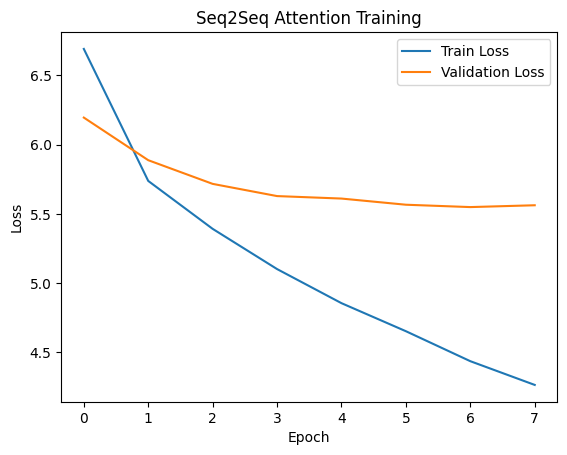

In [22]:
plt.plot(seq_train_losses, label="Train Loss")
plt.plot(seq_val_losses, label="Validation Loss")
plt.title("Seq2Seq Attention Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [23]:
seq2seq_bleu = compute_seq2seq_bleu(seq2seq_model, test_loader, SRC_PAD_IDX, tgt_itos)
print("Seq2Seq Test BLEU:", round(seq2seq_bleu, 2))

Seq2Seq Test BLEU: 3.7


In [24]:
seq2seq_model.eval()

src, tgt = next(iter(test_loader))
src = src[:5].to(device)
tgt = tgt[:5]

with torch.no_grad():
    preds = seq2seq_model.greedy_decode(src, SRC_PAD_IDX, max_len=20).cpu().numpy()

for i in range(5):
    src_tokens = ids_to_tokens(src[i].cpu().numpy()[1:], src_itos)
    tgt_tokens = ids_to_tokens(tgt[i].numpy()[1:], tgt_itos)
    pred_tokens = ids_to_tokens(preds[i], tgt_itos)

    print("SRC :", " ".join(src_tokens))
    print("REF :", " ".join(tgt_tokens))
    print("PRED:", " ".join(pred_tokens))
    print("-" * 80)

SRC : your idea of the <unk> is delightful . we will go round the park every day .
REF : votre idée de <unk> est charmante ; tous les jours nous ferons le tour du <unk> .
PRED: votre de la de la de la de .
--------------------------------------------------------------------------------
SRC : en <unk> d ’ un <unk> <unk> je <unk> le <unk> d ’ un <unk> .
REF : in the face of such a <unk> as that , i shall <unk> a <unk> figure . "
PRED: " i am that the , the , the , " .
--------------------------------------------------------------------------------
SRC : phileas fogg was free !
REF : phileas fogg était libre !
PRED: " , , ,
--------------------------------------------------------------------------------
SRC : the bridge at medicine bow is <unk> , and would not <unk> the weight of the train . "
REF : le pont de medicine - <unk> est <unk> et ne <unk> pas le poids du train . »
PRED: la ' ils ' ils ne , et ne pas , et la .
----------------------------------------------------------------------

## Discussion

The seq2seq attention model showed consistent learning, since both training and validation loss decreased over time. However, the validation loss stayed noticeably higher than the training loss, which suggests limited generalization. The example translations show that the model learned some basic target-language structure, but many outputs are repetitive, incomplete, or contain incorrect word choices. Overall, the model captured partial translation patterns, but performance was still weak on this dataset and training setup.

## Part 4: Simplified Transformer from scratch

This Transformer follows the required simplifications:

- 2 encoder layers
- 2 decoder layers
- 2 attention heads
- embedding dimension = 64
- feedforward dimension = 128
- same dataset as the seq2seq model
- word-level tokenization
- sinusoidal positional encoding
- scaled dot-product attention

In [25]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [26]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=64, num_heads=2, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.attn = ScaledDotProductAttention(dropout=dropout)

    def split_heads(self, x):
        bsz, seq_len, d_model = x.shape
        x = x.view(bsz, seq_len, self.num_heads, self.head_dim)
        return x.transpose(1, 2)

    def combine_heads(self, x):
        bsz, heads, seq_len, head_dim = x.shape
        x = x.transpose(1, 2).contiguous()
        return x.view(bsz, seq_len, heads * head_dim)

    def forward(self, q, k, v, mask=None):
        q = self.split_heads(self.q_proj(q))
        k = self.split_heads(self.k_proj(k))
        v = self.split_heads(self.v_proj(v))

        if mask is not None and mask.dim() == 3:
            mask = mask.unsqueeze(1)

        attn_out, attn_weights = self.attn(q, k, v, mask)
        out = self.combine_heads(attn_out)
        out = self.out_proj(out)
        return out, attn_weights

In [27]:
class FeedForward(nn.Module):
    def __init__(self, d_model=64, d_ff=128, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

### Encoder and decoder blocks

The Transformer blocks include self-attention, feedforward layers, residual connections, and layer normalization.  
The decoder also includes masked attention so it cannot look ahead at future target tokens.

In [28]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model=64, num_heads=2, d_ff=128, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        attn_out, _ = self.self_attn(x, x, x, src_mask)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x

In [29]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model=64, num_heads=2, d_ff=128, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, tgt_mask, src_mask):
        self_attn_out, _ = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(self_attn_out))

        cross_attn_out, _ = self.cross_attn(x, enc_out, enc_out, src_mask)
        x = self.norm2(x + self.dropout(cross_attn_out))

        ff_out = self.ff(x)
        x = self.norm3(x + self.dropout(ff_out))
        return x

In [30]:
class SimplifiedTransformer(nn.Module):
    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        src_pad_idx,
        tgt_pad_idx,
        d_model=64,
        num_heads=2,
        d_ff=128,
        num_encoder_layers=2,
        num_decoder_layers=2,
        max_len=200,
        dropout=0.1
    ):
        super().__init__()

        self.src_pad_idx = src_pad_idx
        self.tgt_pad_idx = tgt_pad_idx
        self.d_model = d_model

        self.src_embed = nn.Embedding(src_vocab_size, d_model, padding_idx=src_pad_idx)
        self.tgt_embed = nn.Embedding(tgt_vocab_size, d_model, padding_idx=tgt_pad_idx)
        self.pos_encoding = PositionalEncoding(d_model, max_len=max_len)

        self.encoders = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_encoder_layers)
        ])
        self.decoders = nn.ModuleList([
            DecoderBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_decoder_layers)
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)

    def make_src_mask(self, src):
        return (src != self.src_pad_idx).unsqueeze(1).unsqueeze(2)

    def make_tgt_mask(self, tgt):
        pad_mask = (tgt != self.tgt_pad_idx).unsqueeze(1).unsqueeze(2)
        seq_len = tgt.size(1)
        subsequent_mask = torch.tril(torch.ones((seq_len, seq_len), device=tgt.device)).bool()
        subsequent_mask = subsequent_mask.unsqueeze(0).unsqueeze(1)
        return pad_mask & subsequent_mask

    def encode(self, src):
        src_mask = self.make_src_mask(src)
        x = self.src_embed(src) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)

        for layer in self.encoders:
            x = layer(x, src_mask)
        return x, src_mask

    def decode(self, tgt, enc_out, src_mask):
        tgt_mask = self.make_tgt_mask(tgt)
        x = self.tgt_embed(tgt) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)

        for layer in self.decoders:
            x = layer(x, enc_out, tgt_mask, src_mask)

        return self.fc_out(x)

    def forward(self, src, tgt_input):
        enc_out, src_mask = self.encode(src)
        logits = self.decode(tgt_input, enc_out, src_mask)
        return logits

    def greedy_decode(self, src, bos_idx, eos_idx, max_len=20):
        self.eval()
        with torch.no_grad():
            enc_out, src_mask = self.encode(src)

            ys = torch.full((src.size(0), 1), bos_idx, dtype=torch.long, device=src.device)

            for _ in range(max_len):
                logits = self.decode(ys, enc_out, src_mask)
                next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
                ys = torch.cat([ys, next_token], dim=1)

            return ys[:, 1:]

In [31]:
transformer_model = SimplifiedTransformer(
    src_vocab_size=len(src_stoi),
    tgt_vocab_size=len(tgt_stoi),
    src_pad_idx=SRC_PAD_IDX,
    tgt_pad_idx=TGT_PAD_IDX,
    d_model=64,
    num_heads=2,
    d_ff=128,
    num_encoder_layers=2,
    num_decoder_layers=2,
    max_len=100,
    dropout=0.1
).to(device)

transformer_optimizer = torch.optim.Adam(transformer_model.parameters(), lr=1e-3)
transformer_criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)

sum(p.numel() for p in transformer_model.parameters())

1502897

In [32]:
def train_transformer_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)

        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        optimizer.zero_grad()
        logits = model(src, tgt_input)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt_output.reshape(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate_transformer_loss(model, loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]

            logits = model(src, tgt_input)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                tgt_output.reshape(-1)
            )
            total_loss += loss.item()

    return total_loss / len(loader)

In [33]:
def compute_transformer_bleu(model, loader, tgt_itos):
    model.eval()
    references = []
    hypotheses = []
    smoothie = SmoothingFunction().method1

    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            pred_ids = model.greedy_decode(src, TGT_BOS_IDX, TGT_EOS_IDX, max_len=20).cpu().numpy()
            tgt_ids = tgt.cpu().numpy()

            for pred_seq, tgt_seq in zip(pred_ids, tgt_ids):
                pred_tokens = ids_to_tokens(pred_seq, tgt_itos)
                tgt_tokens = ids_to_tokens(tgt_seq[1:], tgt_itos)
                references.append([tgt_tokens])
                hypotheses.append(pred_tokens)

    bleu = corpus_bleu(references, hypotheses, smoothing_function=smoothie)
    return bleu * 100

In [34]:
transformer_train_losses = []
transformer_val_losses = []

start_time = time.time()

for epoch in range(8):
    train_loss = train_transformer_epoch(transformer_model, train_loader, transformer_optimizer, transformer_criterion)
    val_loss = evaluate_transformer_loss(transformer_model, val_loader, transformer_criterion)

    transformer_train_losses.append(train_loss)
    transformer_val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

transformer_train_time = time.time() - start_time
print("Transformer training time (seconds):", round(transformer_train_time, 2))

Epoch 1: train_loss=7.0873, val_loss=5.9512
Epoch 2: train_loss=5.6963, val_loss=5.6337
Epoch 3: train_loss=5.3258, val_loss=5.3433
Epoch 4: train_loss=5.0378, val_loss=5.1719
Epoch 5: train_loss=4.8051, val_loss=5.0439
Epoch 6: train_loss=4.6060, val_loss=4.9455
Epoch 7: train_loss=4.4313, val_loss=4.8859
Epoch 8: train_loss=4.2786, val_loss=4.8251
Transformer training time (seconds): 11.37


### Transformer loss curves

These curves show how the simplified Transformer improves during training and whether it generalizes to the validation set.

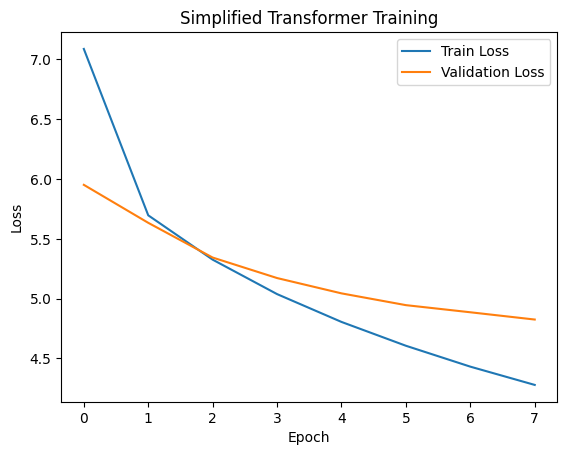

In [35]:
plt.plot(transformer_train_losses, label="Train Loss")
plt.plot(transformer_val_losses, label="Validation Loss")
plt.title("Simplified Transformer Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [36]:
transformer_bleu = compute_transformer_bleu(transformer_model, test_loader, tgt_itos)
print("Transformer Test BLEU:", round(transformer_bleu, 2))

Transformer Test BLEU: 2.26


In [37]:
transformer_model.eval()

src, tgt = next(iter(test_loader))
src = src[:5].to(device)
tgt = tgt[:5]

with torch.no_grad():
    preds = transformer_model.greedy_decode(src, TGT_BOS_IDX, TGT_EOS_IDX, max_len=20).cpu().numpy()

for i in range(5):
    src_tokens = ids_to_tokens(src[i].cpu().numpy()[1:], src_itos)
    tgt_tokens = ids_to_tokens(tgt[i].numpy()[1:], tgt_itos)
    pred_tokens = ids_to_tokens(preds[i], tgt_itos)

    print("SRC :", " ".join(src_tokens))
    print("REF :", " ".join(tgt_tokens))
    print("PRED:", " ".join(pred_tokens))
    print("-" * 80)

SRC : your idea of the <unk> is delightful . we will go round the park every day .
REF : votre idée de <unk> est charmante ; tous les jours nous ferons le tour du <unk> .
PRED: le capitaine nemo le capitaine .
--------------------------------------------------------------------------------
SRC : en <unk> d ’ un <unk> <unk> je <unk> le <unk> d ’ un <unk> .
REF : in the face of such a <unk> as that , i shall <unk> a <unk> figure . "
PRED: the duchessa to the duchessa to the duchessa to the duchessa to the duchessa to the duchessa .
--------------------------------------------------------------------------------
SRC : phileas fogg was free !
REF : phileas fogg était libre !
PRED: chapitre !
--------------------------------------------------------------------------------
SRC : the bridge at medicine bow is <unk> , and would not <unk> the weight of the train . "
REF : le pont de medicine - <unk> est <unk> et ne <unk> pas le poids du train . »
PRED: le lendemain , le roi , le _nautilus_ pas 

## Discussion

The Simplified Transformer also showed steady improvement, with both training and validation loss decreasing more smoothly than the seq2seq model. Its validation loss ended lower, suggesting better generalization overall. In the example translations, the Transformer produced outputs that were still inaccurate, but they were often more structured and fluent than the seq2seq predictions. Even so, many predictions remained repetitive or unrelated to the reference, which likely reflects the small dataset size, simple tokenization, and limited training time.

## Final metric comparison

In [38]:
print(f"Seq2Seq Attention BLEU   : {seq2seq_bleu:.2f}")
print(f"Transformer BLEU         : {transformer_bleu:.2f}")
print(f"Seq2Seq Training Time (s): {seq2seq_train_time:.2f}")
print(f"Transformer Time (s)     : {transformer_train_time:.2f}")

Seq2Seq Attention BLEU   : 3.70
Transformer BLEU         : 2.26
Seq2Seq Training Time (s): 33.39
Transformer Time (s)     : 11.37
